# Cointegration Partielle
In this session, we will assess whether a pair is partially cointegrated and the design a trading strategy based on the Kalman Filter

# Dependencies

In [ ]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Get data

You will need to time series of seemingly co-moving stocks 

Let Y be the first stock and Y the second 

In [3]:
def load_data(filepath, col_X, col_Y, sheet_name=0, start_date=None, end_date=None):
    data = pd.read_excel(filepath, sheet_name=sheet_name, index_col=0)
    if start_date is not None:
        data = data[data.index >= start_date]
    if end_date is not None:
        data = data[data.index <= end_date]
    Y = data[col_Y]
    X = data[col_X]
    return X, Y


# I. Filtre de Kalman

In [12]:
def init_theta(X1, X2):
    """
    Initialisation des paramètres theta = [beta, rho, sigma_m2, sigma_r2].
    - beta : estimé par OLS (X2 = alpha + beta*X1 + erreur)
    - rho : fixé à 0.5 (milieu de [-1, 1])
    - sigma_m2 : variance du bruit de M, initialisée à 0.01
    - sigma_r2 : variance du bruit de R, initialisée à 0.01
    """
    X1_const = sm.add_constant(X1)
    results = sm.OLS(X2, X1_const).fit()
    beta_init = results.params.iloc[1]

    theta_init = np.array([beta_init, 0.5, 0.01, 0.01])
    return theta_init


def build_matrices(theta, sigma_x2):
    """
    Construit les matrices du SSM de Clegg.

    Observation :  X_t = H * Z_t      avec X_t = [X2_t, X1_t]
    Etat :         Z_t = F * Z_{t-1} + W_t   avec Z_t = [X1_t, M_t, R_t]

    theta = [beta, rho, sigma_m2, sigma_r2]
    sigma_x2 = variance empirique de Delta X1 (calculée à part, pas estimée)
    """
    beta, rho, sigma_m2, sigma_r2 = theta

    # Matrice d'observation : X2_t = beta*X1_t + M_t + R_t, et X1_t = X1_t
    H = np.array([
        [beta, 1.0, 1.0],
        [1.0, 0.0, 0.0]
    ])

    # Matrice de transition 
    F = np.array([
        [1.0, 0.0, 0.0],
        [0.0, rho, 0.0],
        [0.0, 0.0, 1.0]
    ])

    # Covariance du bruit d'etat
    # sigma_x2 : bruit de X1 (random walk) — fixé depuis les données
    # sigma_m2 : bruit de M (mean-reverting) — estimé
    # sigma_r2 : bruit de R (random walk du drift) — estimé
    Q = np.array([
        [sigma_x2, 0.0, 0.0],
        [0.0, sigma_m2, 0.0],
        [0.0, 0.0, sigma_r2]
    ])

    return H, F, Q

In [13]:
def kalman_filter(X1, X2, theta):
    """
    Filtre de Kalman complet (états filtrés + loglik).
    Utilisé pour l'affichage post-estimation.
    """
    T = len(X1)
    sigma_x2 = np.var(np.diff(X1))
    H, F, Q = build_matrices(theta, sigma_x2)
    Y = np.column_stack((X2, X1))
    n_state = 3

    z_filt = np.zeros((T, n_state))
    P_filt_store = np.zeros((T, n_state, n_state))
    z_prev = np.array([X1[0], 0.0, 0.0])
    P_prev = np.diag([sigma_x2, 1.0, 1.0])
    I = np.eye(n_state)
    loglik = 0.0

    for t in range(T):
        z_pred = F @ z_prev
        P_pred = F @ P_prev @ F.T + Q
        y_pred = H @ z_pred
        nu = Y[t] - y_pred
        S = H @ P_pred @ H.T
        S = 0.5 * (S + S.T)
        # Analytical 2x2 inverse (faster than np.linalg.inv)
        det = S[0, 0] * S[1, 1] - S[0, 1] * S[1, 0]
        if abs(det) < 1e-15:
            S_inv = np.linalg.pinv(S)
        else:
            S_inv = np.array([[S[1, 1], -S[0, 1]], [-S[1, 0], S[0, 0]]]) / det
        K = P_pred @ H.T @ S_inv
        z_filt_t = z_pred + K @ nu
        P_filt_t = (I - K @ H) @ P_pred
        z_filt[t] = z_filt_t
        P_filt_store[t] = P_filt_t
        log_det = np.log(abs(det) + 1e-15)
        loglik += -0.5 * (log_det + nu @ S_inv @ nu + 2 * np.log(2 * np.pi))
        z_prev = z_filt_t
        P_prev = P_filt_t

    return {
        "z_filt": z_filt,
        "X1_hat": z_filt[:, 0],
        "M_hat": z_filt[:, 1],
        "R_hat": z_filt[:, 2],
        "W_hat": z_filt[:, 1] + z_filt[:, 2],
        "loglik": loglik
    }


def kalman_loglik_ss(X1, X2, theta, n_riccati=60):
    """
    Log-vraisemblance via filtre de Kalman steady-state.
    Beaucoup plus rapide que kalman_filter pour le MLE :
      - Résout la récurrence de Riccati n_riccati fois → K_∞, S_∞ constants
      - La boucle principale ne fait plus d'inversion matricielle

    Utilisé uniquement dans neg_loglik (optimisation).
    """
    T = len(X1)
    sigma_x2 = np.var(np.diff(X1))
    H, F, Q = build_matrices(theta, sigma_x2)
    Y = np.column_stack((X2, X1))
    n_state = 3
    I = np.eye(n_state)

    # ── Riccati burn-in pour obtenir K_∞, S_∞ ──────────────────────────────
    P = np.diag([sigma_x2, 1.0, 1.0])
    for _ in range(n_riccati):
        P_pred = F @ P @ F.T + Q
        S = H @ P_pred @ H.T
        S = 0.5 * (S + S.T)
        det = S[0, 0] * S[1, 1] - S[0, 1] * S[1, 0]
        if abs(det) < 1e-15:
            return -1e12
        S_inv = np.array([[S[1, 1], -S[0, 1]], [-S[1, 0], S[0, 0]]]) / det
        K = P_pred @ H.T @ S_inv
        P = (I - K @ H) @ P_pred

    # Steady-state quantités (constantes pour tous t)
    P_pred_ss = F @ P @ F.T + Q
    S_ss = H @ P_pred_ss @ H.T
    S_ss = 0.5 * (S_ss + S_ss.T)
    det_ss = S_ss[0, 0] * S_ss[1, 1] - S_ss[0, 1] * S_ss[1, 0]
    if abs(det_ss) < 1e-15:
        return -1e12
    S_inv_ss = np.array([[S_ss[1, 1], -S_ss[0, 1]], [-S_ss[1, 0], S_ss[0, 0]]]) / det_ss
    K_ss = P_pred_ss @ H.T @ S_inv_ss
    log_det_ss = np.log(abs(det_ss) + 1e-15)

    # Matrice de transition state → utilise K_ss (précalculée)
    # z_t = F z_{t-1} + K_ss * nu_t   où nu_t = Y_t - H F z_{t-1}
    const = -0.5 * (log_det_ss + 2 * np.log(2 * np.pi))

    # ── Boucle principale : pas d'inversion, juste des produits mat-vec ────
    z = np.array([X1[0], 0.0, 0.0])
    loglik = 0.0
    HF = H @ F  # précalcul

    for t in range(T):
        y_pred = HF @ z
        nu = Y[t] - y_pred
        loglik += const - 0.5 * (nu @ S_inv_ss @ nu)
        z = F @ z + K_ss @ nu

    return loglik


## Estimation par Maximum de Vraisemblance (MLE)

On estime les 4 paramètres $\theta = (\beta, \rho, \sigma_M^2, \sigma_R^2)$ en **maximisant la log-vraisemblance** du filtre de Kalman (= minimiser la negative log-likelihood).

**Contraintes sur les paramètres :**
- $\beta$ : libre (pas de contrainte)
- $\rho \in (-1, 1)$ : coefficient AR(1) du processus mean-reverting
- $\sigma_M^2 > 0$ : variance du bruit de $M_t$
- $\sigma_R^2 > 0$ : variance du bruit de $R_t$ (random walk)

**Initialisation :** $\beta$ via OLS, $\rho = 0.5$, $\sigma_M^2 = \sigma_R^2 = 0.01$

In [14]:
def neg_loglik(params, X1, X2):
    """
    Negative log-likelihood à minimiser.
    Utilise le filtre steady-state (rapide) pendant l'optimisation.
    params = [beta, rho, sigma_m2, sigma_r2]
    """
    beta, rho, sigma_m2, sigma_r2 = params
    if sigma_m2 <= 0 or sigma_r2 <= 0 or abs(rho) >= 1:
        return 1e12
    theta = np.array([beta, rho, sigma_m2, sigma_r2])
    return -kalman_loglik_ss(X1, X2, theta)


def fit_partial_cointegration(X1, X2):
    """
    Estime le modèle de cointégration partielle de Clegg par MLE.
    """
    X1_arr = np.asarray(X1, dtype=float)
    X2_arr = np.asarray(X2, dtype=float)

    theta0 = init_theta(X1, X2)
    print(f"Paramètres initiaux : beta={theta0[0]:.4f}, rho={theta0[1]:.2f}, "
          f"sigma_m2={theta0[2]:.4f}, sigma_r2={theta0[3]:.4f}")

    bounds = [
        (None, None),
        (-0.999, 0.999),
        (0, None),
        (0, None)
    ]

    opt = minimize(neg_loglik, theta0, args=(X1_arr, X2_arr),
                   method='L-BFGS-B', bounds=bounds)

    theta_opt = opt.x
    beta, rho, sigma_m2, sigma_r2 = theta_opt

    # Filtre complet avec états filtrés pour les graphiques
    result = kalman_filter(X1_arr, X2_arr, theta_opt)

    return theta_opt, result, opt


## $R^2$ de Mean Reversion

On utilise la formule:

$$
R^2_{MR} = \frac{\mathrm{Var}(M_t - M_{t-1})}{\mathrm{Var}(W_t - W_{t-1})}
= \frac{\sigma_M^2}{2\sigma_M^2 + (1+\rho)\sigma_R^2}
$$

Interprétation:
- Si $R^2_{MR}$ est élevé: la part mean-reverting domine.
- Si $R^2_{MR}$ est faible: la part random-walk domine (opt-out).

In [15]:
def compute_R2_MR(theta):
    """
    R2_MR = sigma_m2 / (2*sigma_m2 + (1+rho)*sigma_r2)
    theta = [beta, rho, sigma_m2, sigma_r2]
    """
    beta, rho, sigma_m2, sigma_r2 = theta
    denom = 2.0 * sigma_m2 + (1.0 + rho) * sigma_r2
    R2 = sigma_m2 / denom if denom > 0 else np.nan
    return R2


In [ ]:
#X, Y = load_data('Data.xlsx', 'PEP US Equity', 'KO US Equity', sheet_name='PEP_KO', start_date='2016-01-01', end_date='2026-02-20')
X, Y = load_data('Data.xlsx', 'GOOG US Equity', 'GOOGL US Equity', sheet_name='GOOG_GOOGL', start_date='2016-01-01', end_date='2026-02-20')

theta_opt, kf_result, opt = fit_partial_cointegration(X, Y)
R2 = compute_R2_MR(theta_opt)

print('R2_MR =', round(float(R2), 6))


Paramètres initiaux : beta=0.9898, rho=0.50, sigma_m2=0.0100, sigma_r2=0.0100
R2_MR = 0.2854


In [17]:
def rolling_R2_MR(X1, X2, window=252, step=21):
    """
    Calcule et trace le R2_MR au fil du temps via une fenetre glissante.

    Parametres:
    - X1, X2   : series de prix
    - window   : taille de la fenetre (defaut 252 jours ~ 1 an)
    - step     : pas entre deux fenetres (defaut 21 jours ~ 1 mois)
    """
    X1_arr = np.asarray(X1, dtype=float)
    X2_arr = np.asarray(X2, dtype=float)
    index = X1.index if hasattr(X1, 'index') else np.arange(len(X1))

    bounds = [
        (None, None),
        (-0.999, 0.999),
        (1e-8, None),
        (1e-8, None)
    ]

    dates, r2_vals = [], []
    theta_prev = None

    for start in range(0, len(X1_arr) - window + 1, step):
        end = start + window
        x1_w = X1_arr[start:end]
        x2_w = X2_arr[start:end]

        theta0 = theta_prev if theta_prev is not None else init_theta(
            pd.Series(x1_w), pd.Series(x2_w)
        )

        opt = minimize(neg_loglik, theta0, args=(x1_w, x2_w),
                       method='L-BFGS-B', bounds=bounds,
                       options={'maxiter': 200, 'ftol': 1e-9})

        theta_w = opt.x
        beta, rho, sigma_m2, sigma_r2 = theta_w
        denom = 2.0 * sigma_m2 + (1.0 + rho) * sigma_r2
        r2 = sigma_m2 / denom if denom > 0 else np.nan

        dates.append(index[end - 1])
        r2_vals.append(r2)
        theta_prev = theta_w

    r2_series = pd.Series(r2_vals, index=dates, name='R2_MR')

    plt.figure(figsize=(12, 4))
    plt.plot(r2_series, label='R2_MR (rolling)')
    plt.title(f'R2 Mean Reversion au fil du temps (fenetre={window}j, pas={step}j)')
    plt.xlabel('Date')
    plt.ylabel('R2_MR')
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return r2_series


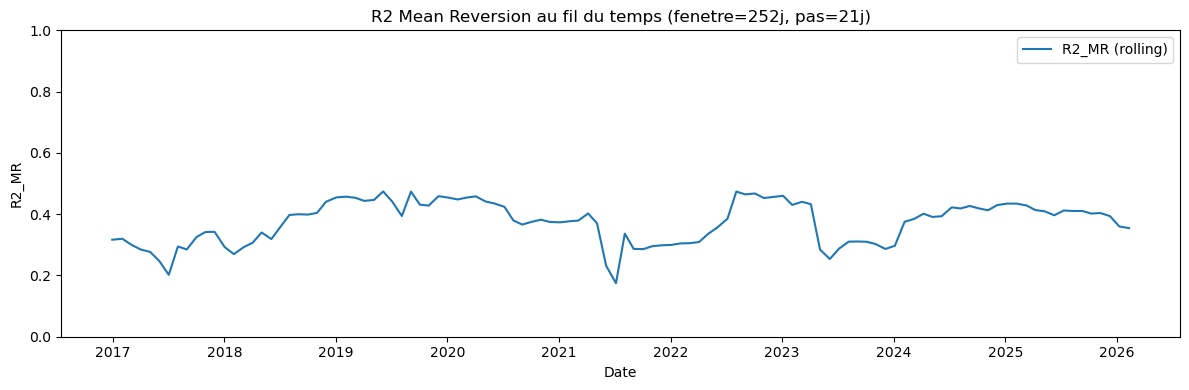

In [ ]:
r2_rolling = rolling_R2_MR(X, Y, window=252, step=21)

Half-life Kalman: 0.51 jours


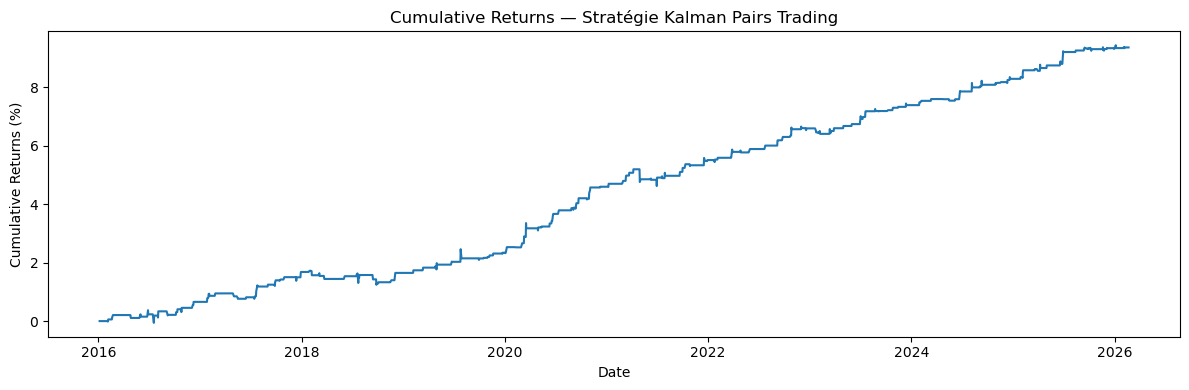

In [19]:
def backtest_strategy(X, Y, spread, beta, half_life, entry_z=2.0, exit_z=0.5):
    window = max(int(2 * half_life), 20)
    positions = pd.Series(0.0, index=spread.index)
    current_pos = 0
    entry_idx = None

    for i in range(window, len(spread)):
        spread_window = spread.iloc[i-window:i]
        mu = spread_window.mean()
        sigma = spread_window.std()
        if sigma == 0:
            continue
        z = (mu - spread.iloc[i]) / sigma

        long_signal  = z >  entry_z
        short_signal = z < -entry_z
        exit_signal  = abs(z) < exit_z

        # Exit
        if current_pos != 0:
            hold_days = i - entry_idx
            if exit_signal or hold_days > int(2 * half_life):
                current_pos = 0
                entry_idx = None

        # Entrée
        if current_pos == 0:
            if long_signal:
                current_pos = 1     # achète Y, vend beta*X
                entry_idx = i
            elif short_signal:
                current_pos = -1    # vend Y, achète beta*X
                entry_idx = i

        positions.iloc[i] = current_pos

    ret_X = X.pct_change()
    ret_Y = Y.pct_change()
    wX = beta / (1 + beta)
    wY = 1 / (1 + beta)

    daily_pnl = positions.shift(1) * (wY * ret_Y - wX * ret_X)
    cum_pnl   = (1 + daily_pnl).cumprod() - 1

    return positions, daily_pnl, cum_pnl * 100


def backtest_kalman(X, Y, theta_opt, kf_result, entry_z=2.0, exit_z=0.5):
    """
    Backteste la stratégie de pairs trading en utilisant le composant
    mean-reverting M_hat issu du filtre de Kalman comme spread.

    - spread  = M_hat  (composante mean-reverting filtrée)
    - beta    = theta_opt[0]
    - rho     = theta_opt[1]  →  half_life = -ln(2) / ln(|rho|)
    """
    beta, rho, _, _ = theta_opt

    # Half-life depuis le coefficient AR(1) rho
    half_life = -np.log(2) / np.log(abs(rho))
    print(f"Half-life Kalman: {round(half_life, 2)} jours")

    # Spread = composante mean-reverting
    M_hat = pd.Series(kf_result['M_hat'], index=X.index)

    positions, daily_pnl, cum_pnl = backtest_strategy(
        X, Y, M_hat, beta, half_life, entry_z=entry_z, exit_z=exit_z
    )

    plt.figure(figsize=(12, 4))
    plt.plot(cum_pnl)
    plt.title('Cumulative Returns — Stratégie Kalman Pairs Trading')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns (%)')
    plt.tight_layout()
    plt.show()

    return positions, daily_pnl, cum_pnl


positions_k, daily_pnl_k, cum_pnl_k = backtest_kalman(X, Y, theta_opt, kf_result)


# II. Analyse des paires S&P 500 par industrie 

In [ ]:
import os
import re

# 1) Charger le snapshot industries (dernier snapshot fourni)
industries = pd.read_parquet(
    r"industries_spx.parquet",
    engine="fastparquet"
).copy()

# 2) Gérer les noms de colonnes possibles
col_ticker = "ticker"
if "industry" in industries.columns:
    col_sector = "industry"
elif "sector" in industries.columns:
    col_sector = "sector"

# Normalisation des tickers (ex: 'AAPL UW Equity' -> 'AAPL')
def norm_ticker(x):
    s = str(x).strip().upper()
    return s.split()[0] if s else s

# Nom Python-safe pour créer des variables par secteur
def sector_to_varname(sector_name):
    s = str(sector_name).strip().lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    if not s:
        s = "sector_unknown"
    if s[0].isdigit():
        s = f"sector_{s}"
    return s

# 3) Construire df_prices si nécessaire (entreprises continues depuis 2015)
if "df_prices" not in globals():
    universe_candidates = [
        r"universe.parquet",
        r"universe.parquet",
    ]
    prices_candidates = [
        r"prices.parquet",
        r"prices.parquet",
    ]

    universe_path = next((p for p in universe_candidates if os.path.exists(p)), None)
    prices_path = next((p for p in prices_candidates if os.path.exists(p)), None)

    if universe_path is None or prices_path is None:
        raise FileNotFoundError(
            "Impossible de trouver universe.parquet / prices.parquet dans les chemins candidats."
        )

    universe = pd.read_parquet(universe_path, engine="fastparquet")
    universe["date"] = pd.to_datetime(universe["date"])

    mask_univ = (universe["date"] >= "2015-01-01") & (universe["date"] <= "2025-12-31")
    univ_period = universe.loc[mask_univ]
    n_dates = univ_period["date"].nunique()

    ticker_counts = univ_period.groupby("ticker")["date"].nunique()
    tickers_always_in = ticker_counts[ticker_counts == n_dates].index.tolist()

    prices = pd.read_parquet(prices_path, engine="fastparquet")
    prices.index = pd.to_datetime(prices.index)
    prices.index.name = "date"

    mask_px = (prices.index >= "2015-01-01") & (prices.index <= "2025-12-31")
    prices_period = prices.loc[mask_px]

    common = [t for t in tickers_always_in if t in prices_period.columns]
    prices_period = prices_period[common]

    no_nan_cols = prices_period.columns[prices_period.notna().all()]
    df_prices = prices_period[no_nan_cols].copy()

# 4) Nettoyage minimal industries
industries = industries[[col_ticker, col_sector]].drop_duplicates(subset=[col_ticker])
industries[col_sector] = industries[col_sector].astype(str).str.strip()
industries["ticker_norm"] = industries[col_ticker].map(norm_ticker)

# 5) Garder uniquement les tickers continus depuis 2015 (via ticker normalisé)
df_ticker_map = pd.DataFrame({
    "ticker_price": df_prices.columns,
    "ticker_norm": [norm_ticker(t) for t in df_prices.columns]
})
continuous_norm = set(df_ticker_map["ticker_norm"])

industries_cont = industries[industries["ticker_norm"].isin(continuous_norm)].copy()

# 6) Supprimer les tickers sans secteur/industrie renseigné
invalid_sector = industries_cont[col_sector].isin(["", "nan", "None", "NaN", "N/A", "Unknown"])
industries_cont = industries_cont[~invalid_sector & industries_cont[col_sector].notna()].copy()

# 7) Construire map secteur par ticker normalisé
sector_map_norm = industries_cont.drop_duplicates(subset=["ticker_norm"]).set_index("ticker_norm")[col_sector]

# Mapper chaque ticker de prix vers son secteur via ticker normalisé
df_ticker_map["sector"] = df_ticker_map["ticker_norm"].map(sector_map_norm)

tickers_with_sector = df_ticker_map.loc[df_ticker_map["sector"].notna(), "ticker_price"].tolist()
df_prices_with_sector = df_prices[tickers_with_sector].copy()

# 8) Créer un DataFrame différent par secteur (dates en index, entreprises en colonnes)
sector_dfs = {}
sector_varname_map = {}

for sector, tickers_sector in df_ticker_map.dropna(subset=["sector"]).groupby("sector"):
    cols = tickers_sector["ticker_price"].tolist()
    if len(cols) == 0:
        continue

    df_sector = df_prices_with_sector[cols].copy()
    df_sector.index.name = "date"

    # Dictionnaire principal: clé = nom lisible du secteur
    sector_dfs[sector] = df_sector

    # Variable Python-safe avec le nom du secteur
    varname = sector_to_varname(sector)
    sector_varname_map[sector] = varname
    globals()[varname] = df_sector

print(f"Tickers continus depuis 2015: {len(df_prices.columns)}")
print(f"Tickers avec secteur renseigné: {len(tickers_with_sector)}")
print(f"Nombre de DataFrames secteurs créés: {len(sector_dfs)}")

print("\nExemples de noms de variables créées:")
for i, (sector, varname) in enumerate(sector_varname_map.items()):
    if i >= 10:
        break
    print(f"- {sector} -> {varname}")

list(sector_dfs.keys())[:10]

Tickers continus depuis 2015: 295
Tickers avec secteur renseigné: 295
Nombre de DataFrames secteurs créés: 25

Exemples de noms de variables créées:
- Automobiles & Components -> automobiles_components
- Banks -> banks
- Capital Goods -> capital_goods
- Commercial & Professional Serv -> commercial_professional_serv
- Consumer Discretionary Distrib -> consumer_discretionary_distrib
- Consumer Durables & Apparel -> consumer_durables_apparel
- Consumer Services -> consumer_services
- Consumer Staples Distribution -> consumer_staples_distribution
- Energy -> energy
- Equity Real Estate Investment -> equity_real_estate_investment


['Automobiles & Components',
 'Banks',
 'Capital Goods',
 'Commercial & Professional Serv',
 'Consumer Discretionary Distrib',
 'Consumer Durables & Apparel',
 'Consumer Services',
 'Consumer Staples Distribution',
 'Energy',
 'Equity Real Estate Investment']

In [167]:
from itertools import combinations

def scan_sector(df_sector, sector_name, R2_seuil=0.0, coint_pval_max=0.10):
    """
    Pour chaque paire unique de tickers dans df_sector :
      1) Pré-filtre rapide : test de cointégration Engle-Granger (statsmodels)
         → on ne garde que les paires avec p-value <= coint_pval_max
      2) Pour les paires retenues : estime le modèle partiel par MLE (Kalman)
         et calcule R2_MR

    Paramètres :
    - df_sector      : DataFrame (dates x tickers) de prix
    - sector_name    : nom du secteur
    - R2_seuil       : ne garder que les paires avec R2_MR >= seuil
    - coint_pval_max : seuil du pré-filtre (défaut 0.10)
    """
    bounds = [
        (None, None),
        (-0.999, 0.999),
        (1e-8, None),
        (1e-8, None),
    ]

    tickers = df_sector.columns.tolist()
    pairs = list(combinations(tickers, 2))
    results = []
    n_prefiltered = 0

    for t1, t2 in pairs:
        s1 = df_sector[t1].dropna()
        s2 = df_sector[t2].dropna()
        idx = s1.index.intersection(s2.index)
        if len(idx) < 60:
            continue
        X1 = s1.loc[idx].values
        X2 = s2.loc[idx].values

        # ── Pré-filtre : test cointégration rapide ──────────────────────────
        try:
            pval = coint(X1, X2)[1]
        except Exception:
            continue
        if pval > coint_pval_max:
            continue
        n_prefiltered += 1

        # ── MLE Kalman ───────────────────────────────────────────────────────
        try:
            theta0 = init_theta(pd.Series(X1), pd.Series(X2))
            opt = minimize(
                neg_loglik, theta0, args=(X1, X2),
                method='L-BFGS-B', bounds=bounds,
                options={'maxiter': 150, 'ftol': 1e-7}
            )
            beta, rho, sigma_m2, sigma_r2 = opt.x
            denom = 2.0 * sigma_m2 + (1.0 + rho) * sigma_r2
            R2 = sigma_m2 / denom if denom > 0 else np.nan

            if np.isnan(R2) or R2 < R2_seuil:
                continue

            results.append({
                'sector':    sector_name,
                'ticker_X':  t1,
                'ticker_Y':  t2,
                'beta':      round(float(beta), 4),
                'rho':       round(float(rho), 4),
                'sigma_m2':  round(float(sigma_m2), 6),
                'sigma_r2':  round(float(sigma_r2), 6),
                'R2_MR':     round(float(R2), 4),
                'loglik':    round(float(-opt.fun), 2),
                'coint_pval': round(float(pval), 4),
                'converged': bool(opt.success),
            })
        except Exception:
            continue

    df_res = pd.DataFrame(results)
    if not df_res.empty:
        df_res = df_res.sort_values('R2_MR', ascending=False).reset_index(drop=True)
    return df_res, n_prefiltered
